**Import Library dan Load Dataset**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('ecommerce_orders_staging_100k.csv')

df.head()

,order_id,customer_id,merchant_id,category,item_count,unit_price,total_amount,order_status,payment_method,order_date
0,ORD-100000,CUST-8270,MCH-797,Home & Kitchen,1,33.90,38.89,Processing,UPI / NetBanking,2026-05-11
1,ORD-100001,CUST-1860,MCH-577,Electronics,1,104.24,104.24,Delivered,PayPal,2026-07-06
2,ORD-100002,CUST-6390,MCH-385,Health & Personal Care,1,36.05,36.05,Delivered,Stripe,2026-07-29
3,ORD-100003,CUST-6191,MCH-419,Electronics,1,49.24,49.24,Delivered,PayPal,2026-05-06
4,ORD-100004,CUST-6734,MCH-733,Books & Media,1,29.74,29.74,Delivered,Stripe,2026-08-14


Melakukan Pengecekan Missing Values

In [31]:
df.info()

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        100000 non-null  object 
 1   customer_id     100000 non-null  object 
 2   merchant_id     100000 non-null  object 
 3   category        100000 non-null  object 
 4   item_count      100000 non-null  int64  
 5   unit_price      100000 non-null  float64
 6   total_amount    100000 non-null  float64
 7   order_status    100000 non-null  object 
 8   payment_method  100000 non-null  object 
 9   order_date      100000 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 7.6+ MB
order_id          0
customer_id       0
merchant_id       0
category          0
item_count        0
unit_price        0
total_amount      0
order_status      0
payment_method    0
order_date        0
dtype: int64


Pembersihan Data (Data Cleaning)

In [32]:
# Mengubah tipe kolom order_date menjadi datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Menghitung biaya pengiriman tersembunyi (total_amount - (unit_price * item_count))
df['subtotal'] = df['unit_price'] * df['item_count']
df['shipping_fee'] = (df['total_amount'] - df['subtotal']).round(2)

# Tampilkan ringkasan statistik angka
df[['unit_price', 'item_count', 'total_amount', 'shipping_fee']].describe()


,unit_price,item_count,total_amount,shipping_fee
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,43.603831,1.757560,80.328822,3.974871
std,35.077440,1.037716,83.544817,3.733662
min,8.500000,1.000000,8.500000,0.000000
25%,18.670000,1.000000,30.507500,0.000000
50%,32.800000,1.000000,53.400000,4.990000
75%,57.150000,2.000000,97.760000,4.990000
max,473.780000,5.000000,1844.940000,9.990000


In [33]:
print("Jumlah Toko/Merchant Unik :", df['merchant_id'].nunique())
print("Jumlah Pembeli/Customer Unik:", df['customer_id'].nunique())

Jumlah Toko/Merchant Unik : 700
Jumlah Pembeli/Customer Unik: 8999


Visualisasi Grafik Status Pesanan

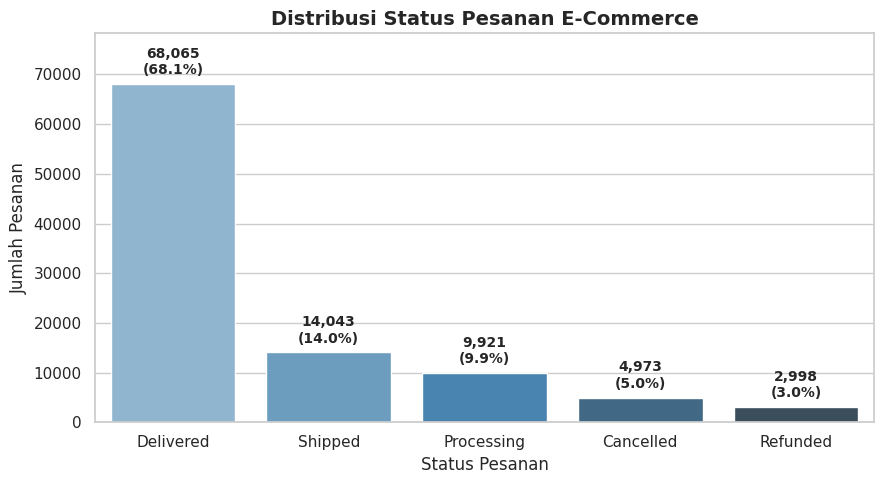

In [34]:
# Hitung jumlah pesanan per status
status_counts = df['order_status'].value_counts().reset_index()
status_counts.columns = ['order_status', 'count']

plt.figure(figsize=(9, 5))
grafik5 = sns.barplot(
    data=status_counts,
    x='order_status',
    y='count',
    hue='order_status',
    palette="Blues_d",
    legend=False
)

plt.title("Distribusi Status Pesanan E-Commerce", fontsize=14, fontweight='bold')
plt.xlabel("Status Pesanan", fontsize=12)
plt.ylabel("Jumlah Pesanan", fontsize=12)
plt.ylim(0, status_counts['count'].max() * 1.15)

total_order = len(df)
for p in grafik5.patches:
    tinggi = p.get_height()
    persen = (tinggi / total_order) * 100
    grafik5.annotate(
        f'{int(tinggi):,}\n({persen:.1f}%)',
        (p.get_x() + p.get_width() / 2., tinggi),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Menghitung GMV & Jumlah Pesanan per Kategori

In [35]:
# Group data berdasarkan kategori, terus hitung total order dan total duit masuk
ringkasan_kategori = df.groupby('category').agg(
    total_order=('order_id', 'count'),
    total_pendapatan=('total_amount', 'sum'),
    rata_rata_belanja=('total_amount', 'mean')
).reset_index()

# Urutin dari kategori yang bikin paling banyak cuan
ringkasan_kategori = ringkasan_kategori.sort_values(by='total_pendapatan', ascending=False)

# Rapihin format angkanya biar enak dibaca
ringkasan_kategori['total_pendapatan_fmt'] = ringkasan_kategori['total_pendapatan'].apply(lambda x: f"${x:,.2f}")
ringkasan_kategori['rata_rata_belanja_fmt'] = ringkasan_kategori['rata_rata_belanja'].apply(lambda x: f"${x:,.2f}")

print("=== MANA KATEGORI YANG PALING CUAN? ===")
print(ringkasan_kategori[['category', 'total_order', 'total_pendapatan_fmt', 'rata_rata_belanja_fmt']])

=== MANA KATEGORI YANG PALING CUAN? ===
                 category  total_order total_pendapatan_fmt  \
2             Electronics        24938        $2,009,544.34   
0       Apparel & Fashion        25023        $2,004,865.71   
4          Home & Kitchen        18133        $1,465,694.84   
3  Health & Personal Care        13822        $1,104,593.00   
1           Books & Media         9969          $792,381.56   
5        Sports & Fitness         8115          $655,802.72   

  rata_rata_belanja_fmt  
2                $80.58  
0                $80.12  
4                $80.83  
3                $79.92  
1                $79.48  
5                $80.81  


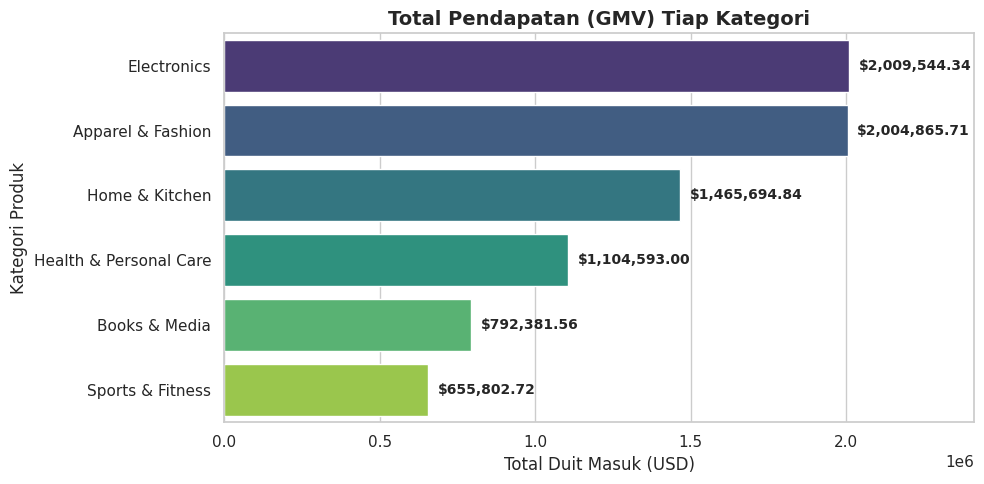

In [36]:
plt.figure(figsize=(10, 5))

grafik6 = sns.barplot(
    data=ringkasan_kategori,
    y='category',
    x='total_pendapatan',
    hue='category',
    palette='viridis',
    legend=False
)

plt.title("Total Pendapatan (GMV) Tiap Kategori", fontsize=14, fontweight='bold')
plt.xlabel("Total Duit Masuk (USD)", fontsize=12)
plt.ylabel("Kategori Produk", fontsize=12)
plt.xlim(0, ringkasan_kategori['total_pendapatan'].max() * 1.2)

for p in grafik6.patches:
    panjang = p.get_width()
    grafik6.annotate(
        f'${panjang:,.2f}',
        (panjang, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(7, 0), textcoords='offset points',
        fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Menghitung Jumlah Orderan Berdasarkan Biaya Pengiriman

=== PERTIMBANGAN ONGKIR PELANGGAN ===
  label_ongkir  jumlah_order  persentase
0        $0.00         40213      40.213
1        $4.99         39957      39.957
2        $9.99         19830      19.830


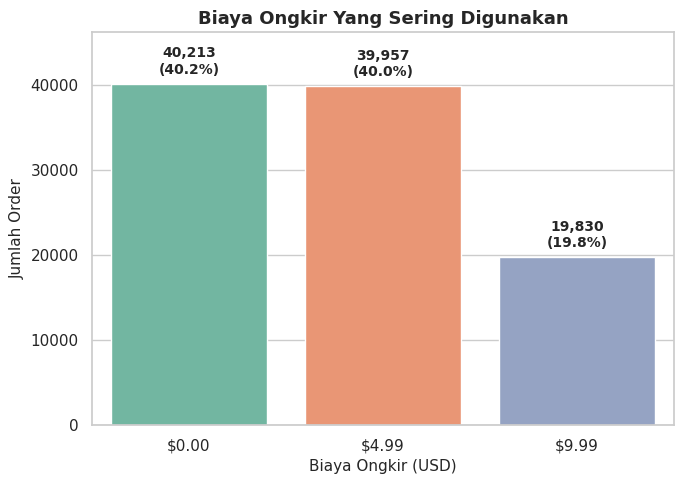

In [37]:
# Hitung berapa banyak yang pakai ongkir gratis, standar, atau ekspres
pilihan_ongkir = df['shipping_fee'].value_counts().reset_index()
pilihan_ongkir.columns = ['biaya_ongkir', 'jumlah_order']
pilihan_ongkir['persentase'] = (pilihan_ongkir['jumlah_order'] / len(df)) * 100

# Bikin label harga ongkirnya
pilihan_ongkir['label_ongkir'] = pilihan_ongkir['biaya_ongkir'].apply(lambda x: f"${x:.2f}")

print("=== PERTIMBANGAN ONGKIR PELANGGAN ===")
print(pilihan_ongkir[['label_ongkir', 'jumlah_order', 'persentase']])

# Visualisasi Pilihan Ongkir dengan Angka di Atas Diagram
plt.figure(figsize=(7, 5))
grafik7a = sns.barplot(
    data=pilihan_ongkir,
    x='label_ongkir',
    y='jumlah_order',
    hue='label_ongkir',
    palette='Set2',
    legend=False
)

plt.title("Biaya Ongkir Yang Sering Digunakan", fontsize=13, fontweight='bold')
plt.xlabel("Biaya Ongkir (USD)", fontsize=11)
plt.ylabel("Jumlah Order", fontsize=11)
plt.ylim(0, pilihan_ongkir['jumlah_order'].max() * 1.15)


total_order = len(df)
for p in grafik7a.patches:
    tinggi = p.get_height()
    persen = (tinggi / total_order) * 100
    grafik7a.annotate(
        f'{int(tinggi):,}\n({persen:.1f}%)',
        (p.get_x() + p.get_width() / 2., tinggi),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Menghitung Metode Pembayaran Yang Sering Digunakan

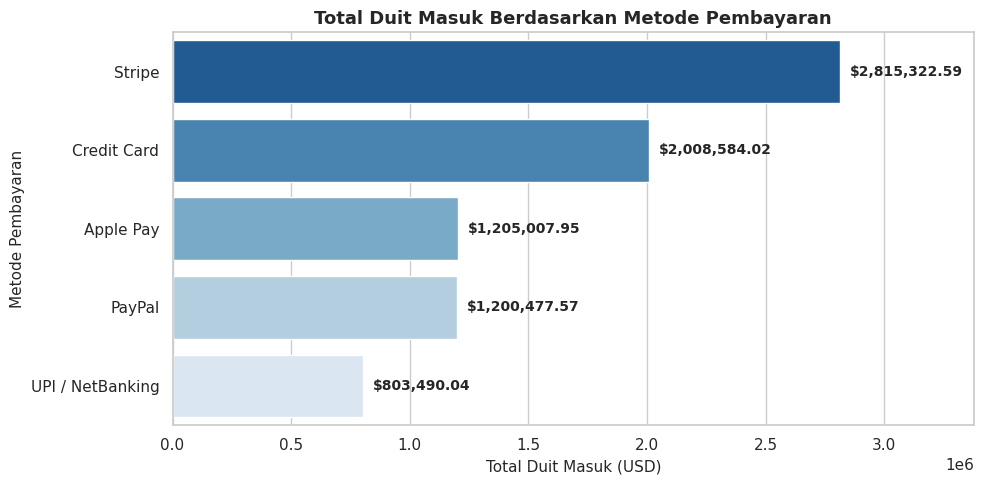

In [38]:
# Hitung total transaksi per metode pembayaran
ringkasan_bayar = df.groupby('payment_method').agg(
    total_order=('order_id', 'count'),
    total_pendapatan=('total_amount', 'sum')
).reset_index().sort_values(by='total_pendapatan', ascending=False)

# Bikin grafiknya dengan label angka
plt.figure(figsize=(10, 5))
grafik7b = sns.barplot(
    data=ringkasan_bayar,
    x='total_pendapatan',
    y='payment_method',
    hue='payment_method',
    palette='Blues_r',
    legend=False
)

plt.title("Total Duit Masuk Berdasarkan Metode Pembayaran", fontsize=13, fontweight='bold')
plt.xlabel("Total Duit Masuk (USD)", fontsize=11)
plt.ylabel("Metode Pembayaran", fontsize=11)

plt.xlim(0, ringkasan_bayar['total_pendapatan'].max() * 1.2)

for p in grafik7b.patches:
    panjang = p.get_width()
    grafik7b.annotate(
        f'${panjang:,.2f}',
        (panjang, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(7, 0), textcoords='offset points',
        fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Analisis Perilaku Pelanggan

In [39]:
# Tentukan tanggal acuan (tanggal paling akhir di dataset)
tanggal_patokan = df['order_date'].max() + pd.Timedelta(days=1)

# Hitung Recency, Frequency, dan Monetary buat setiap customer_id
rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (tanggal_patokan - x.max()).days,  # Recency (dalam hari)
    'order_id': 'count',                                        # Frequency (jumlah transaksi)
    'total_amount': 'sum'                                       # Monetary (total duit belanja)
}).reset_index()

# Ganti nama kolomnya biar enak dibaca
rfm.columns = ['customer_id', 'recency_hari', 'frekuensi_order', 'total_belanja']

print("=== RINGKASAN PERILAKU PELANGGAN (RFM) ===")
print(rfm.describe())

=== RINGKASAN PERILAKU PELANGGAN (RFM) ===
       recency_hari  frekuensi_order  total_belanja
count   8999.000000      8999.000000    8999.000000
mean      17.050006        11.112346     892.641646
std       16.583410         3.322440     388.393255
min        1.000000         2.000000      70.200000
25%        5.000000         9.000000     612.760000
50%       12.000000        11.000000     837.480000
75%       23.000000        13.000000    1115.405000
max      141.000000        24.000000    3279.010000


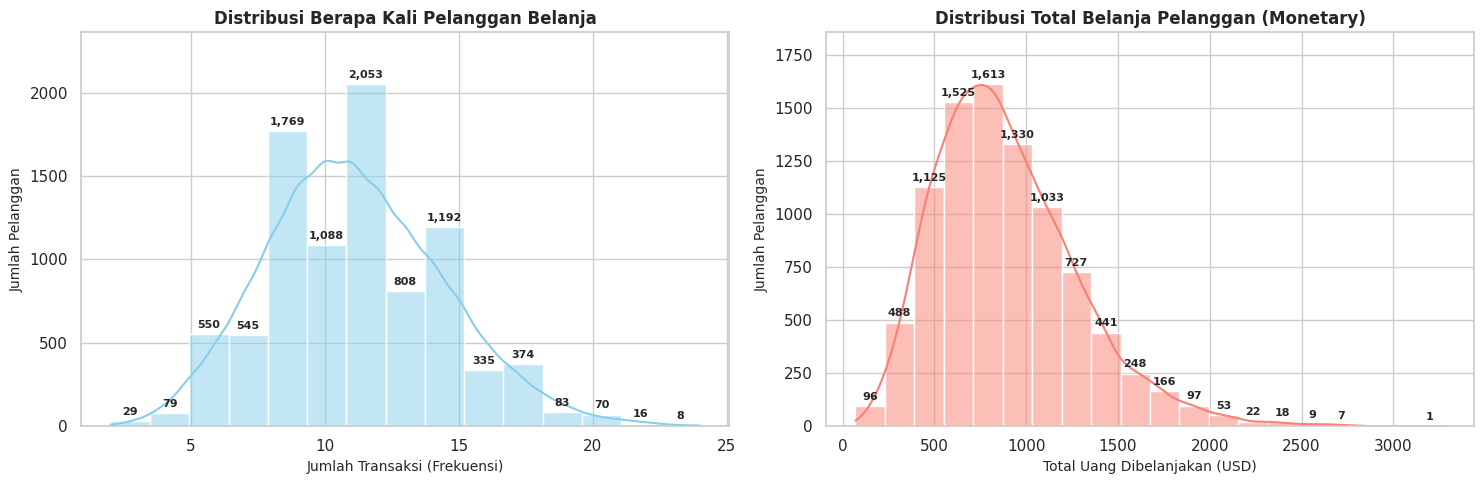

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Grafik Frekuensi Order per Pelanggan
g1 = sns.histplot(rfm['frekuensi_order'], bins=15, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Berapa Kali Pelanggan Belanja', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Transaksi (Frekuensi)', fontsize=10)
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=10)
axes[0].set_ylim(0, max([p.get_height() for p in g1.patches]) * 1.15)

for p in g1.patches:
    tinggi = p.get_height()
    if tinggi > 0:
        g1.annotate(
            f'{int(tinggi):,}',
            (p.get_x() + p.get_width() / 2., tinggi),
            ha='center', va='bottom',
            xytext=(0, 3), textcoords='offset points',
            fontsize=8, fontweight='bold'
        )

# 2. Grafik Total Duit yang Dihabiskan per Pelanggan
g2 = sns.histplot(rfm['total_belanja'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Total Belanja Pelanggan (Monetary)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Uang Dibelanjakan (USD)', fontsize=10)
axes[1].set_ylabel('Jumlah Pelanggan', fontsize=10)
axes[1].set_ylim(0, max([p.get_height() for p in g2.patches]) * 1.15)

for p in g2.patches:
    tinggi = p.get_height()
    if tinggi > 0:
        g2.annotate(
            f'{int(tinggi):,}',
            (p.get_x() + p.get_width() / 2., tinggi),
            ha='center', va='bottom',
            xytext=(0, 3), textcoords='offset points',
            fontsize=8, fontweight='bold'
        )

plt.tight_layout()
plt.show()